문제6) 이미지 분류

CIFAR-100 dataset 사용    ( 얘 말고 다른 데이터를 이용해도 됨. 음식, 사무용 집기, 라면(우동) ... )
특징
 - 클래스 수: 100개 (예: 사과, 버스, 산, 고래, 시계 등)
 - 샘플 수: 60,000장, 학습용(train): 50,000장, 테스트용(test): 10,000장
 - 이미지 크기: 32×32 RGB (작은 해상도)
 - 레이블 구조: 100개 fine labels (세부 클래스), 20개 coarse labels (상위 클래스 그룹)

기본 CNN으로도 학습 가능하지만, 성능을 높이려면
 - 데이터 증강(ImageDataGenerator / tf.image)
 - 전이학습(사전학습 모델)
 - 정규화/드롭아웃/배치정규화 등을 함께 쓰는 게 효과적


-- 전체 흐름 요약 --

  작업1 :  CIFAR-100 dataset  분류 모델 작성 (MovileNetV2 모델로 전이학습, 파인튜닝)
  작업2 : 작성한  분류 모델 사용

              웹 브라우저에서 이미지 선택
                   → 장고 웹서버에 저장 → 서버 내부에서 시각화로 확인(matplotlib) + 딥러닝 분류  

                  → 클라이언트에 분류 결과만 반환하기

작업2를 좀더 구체적으로 보면
 1) 클라이언트
    : index.html에서 파일선택 버튼을 눌러 로컬 컴퓨터의 이미지 파일을 선택하고 화면에 선택된 이미지 출력
    : 분류결과요청 버튼 클릭 → AJAX 전송 (axios 모듈 사용)
 2) 서버(Django)
    : 수신된 이미지 파일 저장 → PIL + Matplotlib(imshow)으로 확인 → 딥러닝 분류 모델로 추론
    : 응답(JSON): 분류 결과만 반환(예 : bus)
 3) 클라이언트
    : 기존 이미지 아래에 이미지 분류 결과 문자열을 화면에 출력



In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
(x_train, y_train),(x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Normalization
x_train = x_train.astype('float32') / (255/2)
x_test = x_test.astype('float32') / (255/2)

# one hot
NUM_CLASESS = 100
y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASESS)
y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASESS)

print(f'train data : {x_train.shape}, {y_train.shape}') # (50000, 32, 32, 3), (50000, 100)
print(f'test data : {x_test.shape}, {y_test.shape}')    # (10000, 32, 32, 3), (10000, 100)

train data : (50000, 32, 32, 3), (50000, 100)
test data : (10000, 32, 32, 3), (10000, 100)


In [2]:
# 데이터 증강 ======================================================================================
augment_size = 30000
randidx = np.random.randint(x_train.shape[0], size=augment_size)

# 3만개 선택해서 copy
x_augment = x_train[randidx].copy()
y_augment = y_train[randidx].copy()

img_generate = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,      # 랜덤하게 그림을 10도 회전
    zoom_range=0.1,         # 이미지 10% 확대, 축소
    shear_range=0.1,        # 임의 축을 중심으로 전환(모양 기울이기)
    width_shift_range=0.1,  # 평행 이동(수평)
    height_shift_range=0.1, # 평행 이동(수직)
    horizontal_flip=True,   # 좌우 반전
    vertical_flip=False      # 상하 반전
)

# 증강
gen = img_generate.flow(
                      x_augment,
                      y_augment,
                      batch_size=augment_size,
                      shuffle=False       # 라벨 유지를 위해 셔플 False
    )
x_augmented, y_augmented = next(gen) # 한개씩 batch를 꺼내주는 함수

# 원본에 합치기 : np.concatenate()
print(x_train.shape)    # (50000, 32, 32, 3)
print(y_train.shape)    # (50000, 100)
x_train = np.concatenate([x_train, x_augmented], axis=0)
y_train = np.concatenate([y_train, y_augmented], axis=0)
print(x_train.shape)    # (80000, 32, 32, 3)
print(y_train.shape)    # (80000, 100)

(50000, 32, 32, 3)
(50000, 100)
(80000, 32, 32, 3)
(80000, 100)


In [3]:
# Base Model(백본모델) 불러오기
IMG_SIZE = (96, 96)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3, ),
    include_top=False,
    weights='imagenet'
)
# freeze
base_model.trainable = False

# 모델 생성하기(원본데이터를변형 + 전이 + 분류기)
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=IMG_SIZE + (3, )),
    tf.keras.layers.Resizing(96, 96),
    base_model,         # 전이 학습
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(rate=0.3),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(rate=0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.3),

    tf.keras.layers.Dense(NUM_CLASESS, activation='softmax')
])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,631,716 (10.04 MB)

 Trainable params: 373,732 (1.43 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [4]:
# compile / fit
model.compile(
     optimizer='adam',
     loss='categorical_crossentropy',
     metrics=['accuracy']
 )

# callback 사전 설정
import os
MODEL_DIR = './cifar100/'
if not os.path.exists(MODEL_DIR):
  os.mkdir(MODEL_DIR)

modelpath = MODEL_DIR+'{epoch:02d}_{val_loss:.2f}.keras'
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=modelpath,
        monitor='val_loss',
        verbose=1,
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=100,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0994 - loss: 4.0493
Epoch 1: val_loss improved from None to 2.69413, saving model to ./cifar100/01_2.69.keras

Epoch 1: finished saving model to ./cifar100/01_2.69.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.1771 - loss: 3.4941 - val_accuracy: 0.3283 - val_loss: 2.6941 - learning_rate: 0.0010
Epoch 2/100
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3079 - loss: 2.7169
Epoch 2: val_loss improved from 2.69413 to 2.47382, saving model to ./cifar100/02_2.47.keras

Epoch 2: finished saving model to ./cifar100/02_2.47.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.3204 - loss: 2.6645 - val_accuracy: 0.3844 - val_loss: 2.4738 - learning_rate: 0.0010
Epoch 3/100
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3598 - loss: 2.4700
Epoch 3: val_loss improved from 2.47382 to 2.36147, saving model to ./cifar100/03_2.36.keras

Epoch 3: finished saving model to ./cifar100/03_2.36.

In [5]:
# 평가하기
loss, acc = model.evaluate(x_test, y_test)
print(f'loss: {loss:.4f}, acc: {acc:.4f}')

# 모델 저장하기
model.save('cnnquiz2.keras')

313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.5506 - loss: 1.6735
loss: 1.6735, acc: 0.5506


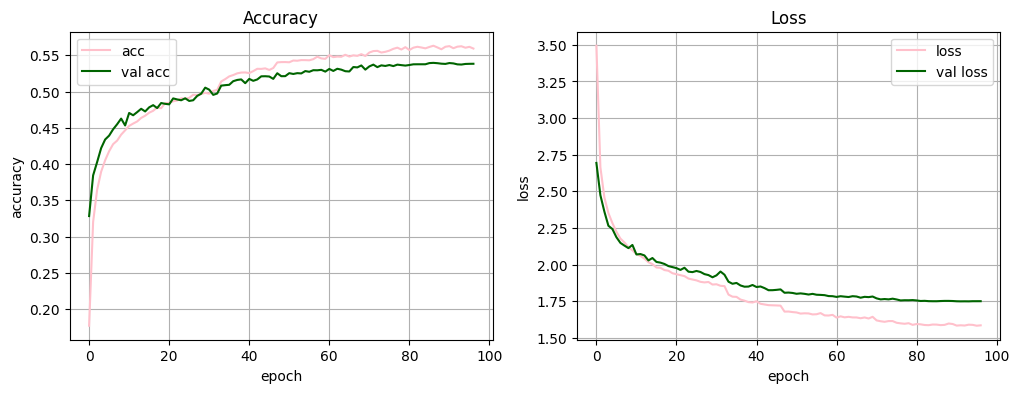

In [6]:
# acc / loss 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='acc', color='pink')
plt.plot(history.history['val_accuracy'], label='val acc', color='darkgreen')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss', color='pink')
plt.plot(history.history['val_loss'], label='val loss', color='darkgreen')
plt.title('Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()